# Creating CTT (Text-Grammar) files from BHSA passages

## Loading the Workbench

In [13]:
import sys, os, collections
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt; plt.rcdefaults()
from matplotlib.pyplot import figure
from collections import Counter
from collections import defaultdict

In [14]:
# First we load the TF program
from tf.fabric import Fabric
from tf.app import use

In [15]:
pd.set_option('display.max_rows', None)

In [16]:
%%time
# Now we load a the BHSA database
BHS = use('etcbc/bhsa', version="2021", mod='CenterBLC/BHSaddons/tf', hoist=globals())
bhsF, bhsL, bhsT, bhsS = BHS.api.F, BHS.api.L, BHS.api.T, BHS.api.S

**Locating corpus resources ...**

Name,# of nodes,# slots / node,% coverage
book,39,10938.21,100
chapter,929,459.19,100
lex,9230,46.22,100
verse,23213,18.38,100
half_verse,45179,9.44,100
sentence,63717,6.70,100
sentence_atom,64514,6.61,100
clause,88131,4.84,100
clause_atom,90704,4.70,100
phrase,253203,1.68,100


CPU times: user 3.04 s, sys: 634 ms, total: 3.68 s
Wall time: 4 s


## Building Text-Grammar relevant TF query

In [17]:
TextGrammarBHS='''
verse book=Reges_I chapter=21 verse*
  clause typ txt* number* rela*
   clause_atom tab* typ* pargr* number* code*
     phrase function* number*
       phrase_atom rela* number*
'''
TextGrammarBHS = BHS.search(TextGrammarBHS)
BHS.show(TextGrammarBHS, start=1, end=1, extraFeatures={'function', 'lex', 'sp', 'typ', 'ls','tab'}, condensed=False)

  0.70s 464 results


In [18]:
BHS.export(TextGrammarBHS, toDir='/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export', toFile='TextGrammarBHS.tsv')

# Loading the Search Results as `df`

In [19]:
TextGrammarBHS=pd.read_csv('/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/TextGrammarBHS.tsv', delimiter='\t', encoding='utf-16')
pd.set_option('display.max_columns', 50)
TextGrammarBHS.head(5)

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,number2,rela2,txt2,typ2,NODE3,TYPE3,TEXT3,code3,number3,pargr3,tab3,typ3,NODE4,TYPE4,TEXT4,function4,number4,NODE5,TYPE5,TEXT5,number5,rela5
0,1,1_Kings,21,1,1423758,verse,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה כֶּ֧רֶם...,Reges_I,21,1,464357,clause,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,1,NaN,N,Way0,553613,clause_atom,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,0,3296,1,0,Way0,762962,phrase,וַ,Conj,1,1022862,phrase_atom,וַ,10385,NaN
1,2,1_Kings,21,1,1423758,verse,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה כֶּ֧רֶם...,Reges_I,21,1,464357,clause,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,1,NaN,N,Way0,553613,clause_atom,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,0,3296,1,0,Way0,762963,phrase,יְהִ֗י,Pred,2,1022863,phrase_atom,יְהִ֗י,10386,NaN
2,3,1_Kings,21,1,1423758,verse,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה כֶּ֧רֶם...,Reges_I,21,1,464357,clause,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,1,NaN,N,Way0,553613,clause_atom,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,0,3296,1,0,Way0,762964,phrase,אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,Time,3,1022864,phrase_atom,אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,10387,NaN
3,4,1_Kings,21,1,1423758,verse,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה כֶּ֧רֶם...,Reges_I,21,1,464358,clause,כֶּ֧רֶם הָיָ֛ה לְנָבֹ֥ות הַיִּזְרְעֵאלִ֖י,1,NaN,N,XQtl,553614,clause_atom,כֶּ֧רֶם הָיָ֛ה לְנָבֹ֥ות הַיִּזְרְעֵאלִ֖י,127,3297,1,1,XQtl,762965,phrase,כֶּ֧רֶם,Subj,1,1022865,phrase_atom,כֶּ֧רֶם,10388,NaN
4,5,1_Kings,21,1,1423758,verse,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה כֶּ֧רֶם...,Reges_I,21,1,464358,clause,כֶּ֧רֶם הָיָ֛ה לְנָבֹ֥ות הַיִּזְרְעֵאלִ֖י,1,NaN,N,XQtl,553614,clause_atom,כֶּ֧רֶם הָיָ֛ה לְנָבֹ֥ות הַיִּזְרְעֵאלִ֖י,127,3297,1,1,XQtl,762966,phrase,הָיָ֛ה,Pred,2,1022866,phrase_atom,הָיָ֛ה,10389,NaN


# Creating SBL conform Book Abbreviations from the BHS Latin Book Names

In [20]:
# Mapping of BHS book names to SBL abbreviations
bhs_to_sbl = {
    'Genesis': 'Gen',
    'Exodus': 'Exod',
    'Leviticus': 'Lev',
    'Numeri': 'Num',
    'Deuteronomium': 'Deut',
    'Josua': 'Josh',
    'Judices': 'Judg',
    'Ruth': 'Ruth',
    'Samuel_I': '1 Sam',
    'Samuel_II': '2 Sam',
    'Reges_I': '1 Kgs',
    'Reges_II': '2 Kgs',
    'Chronica_I': '1 Chr',
    'Chronica_II': '2 Chr',
    'Esra': 'Ezra',
    'Nehemia': 'Neh',
    'Esther': 'Esth',
    'Iob': 'Job',
    'Psalmi': 'Ps',
    'Proverbia': 'Prov',
    'Ecclesiastes': 'Eccl',
    'Canticum': 'Song',
    'Jesaia': 'Isa',
    'Jeremia': 'Jer',
    'Threni': 'Lam',
    'Ezechiel': 'Ezek',
    'Daniel': 'Dan',
    'Hosea': 'Hos',
    'Joel': 'Joel',
    'Amos': 'Amos',
    'Obadia': 'Obad',
    'Jona': 'Jonah',
    'Micha': 'Mic',
    'Nahum': 'Nah',
    'Habakuk': 'Hab',
    'Zephania': 'Zeph',
    'Haggai': 'Hag',
    'Sacharia': 'Zech',
    'Maleachi': 'Mal'
}

In [21]:
TextGrammarBHS['book1_BHS'] = TextGrammarBHS['book1']
TextGrammarBHS['book1'] = TextGrammarBHS['book1'].map(bhs_to_sbl).fillna(TextGrammarBHS['book1'])
TextGrammarBHS.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,book1,chapter1,verse1,NODE2,TYPE2,TEXT2,number2,rela2,txt2,typ2,NODE3,TYPE3,TEXT3,code3,number3,pargr3,tab3,typ3,NODE4,TYPE4,TEXT4,function4,number4,NODE5,TYPE5,TEXT5,number5,rela5,book1_BHS
0,1,1_Kings,21,1,1423758,verse,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה כֶּ֧רֶם...,1 Kgs,21,1,464357,clause,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,1,NaN,N,Way0,553613,clause_atom,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,0,3296,1,0,Way0,762962,phrase,וַ,Conj,1,1022862,phrase_atom,וַ,10385,NaN,Reges_I
1,2,1_Kings,21,1,1423758,verse,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה כֶּ֧רֶם...,1 Kgs,21,1,464357,clause,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,1,NaN,N,Way0,553613,clause_atom,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,0,3296,1,0,Way0,762963,phrase,יְהִ֗י,Pred,2,1022863,phrase_atom,יְהִ֗י,10386,NaN,Reges_I
2,3,1_Kings,21,1,1423758,verse,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה כֶּ֧רֶם...,1 Kgs,21,1,464357,clause,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,1,NaN,N,Way0,553613,clause_atom,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,0,3296,1,0,Way0,762964,phrase,אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,Time,3,1022864,phrase_atom,אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה,10387,NaN,Reges_I
3,4,1_Kings,21,1,1423758,verse,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה כֶּ֧רֶם...,1 Kgs,21,1,464358,clause,כֶּ֧רֶם הָיָ֛ה לְנָבֹ֥ות הַיִּזְרְעֵאלִ֖י,1,NaN,N,XQtl,553614,clause_atom,כֶּ֧רֶם הָיָ֛ה לְנָבֹ֥ות הַיִּזְרְעֵאלִ֖י,127,3297,1,1,XQtl,762965,phrase,כֶּ֧רֶם,Subj,1,1022865,phrase_atom,כֶּ֧רֶם,10388,NaN,Reges_I
4,5,1_Kings,21,1,1423758,verse,וַיְהִ֗י אַחַר֙ הַדְּבָרִ֣ים הָאֵ֔לֶּה כֶּ֧רֶם...,1 Kgs,21,1,464358,clause,כֶּ֧רֶם הָיָ֛ה לְנָבֹ֥ות הַיִּזְרְעֵאלִ֖י,1,NaN,N,XQtl,553614,clause_atom,כֶּ֧רֶם הָיָ֛ה לְנָבֹ֥ות הַיִּזְרְעֵאלִ֖י,127,3297,1,1,XQtl,762966,phrase,הָיָ֛ה,Pred,2,1022866,phrase_atom,הָיָ֛ה,10389,NaN,Reges_I


# Creating a CTT like Text-Grammar print

In [22]:
from docx import Document
from docx.shared import Pt, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
import pandas as pd
import re

df = TextGrammarBHS  # your dataframe

# Regex for Hebrew characters
HEBREW_RE = re.compile(r'[\u0590-\u05FF\uFB1D-\uFB4F]+|[^\u0590-\u05FF\uFB1D-\uFB4F]+')

def is_hebrew_char(ch: str) -> bool:
    code = ord(ch)
    return (0x0590 <= code <= 0x05FF) or (0xFB1D <= code <= 0xFB4F)

def split_hebrew_nonhebrew(text: str):
    for m in HEBREW_RE.finditer(text):
        seg = m.group(0)
        yield seg, bool(is_hebrew_char(seg[0]))

def set_run_font(run, font_name: str, size_pt: float = None):
    run.font.name = font_name
    if size_pt:
        run.font.size = Pt(size_pt)
    r = run._element
    rPr = r.get_or_add_rPr()
    rFonts = OxmlElement('w:rFonts')
    rFonts.set(qn('w:ascii'), font_name)
    rFonts.set(qn('w:hAnsi'), font_name)
    rFonts.set(qn('w:cs'), font_name)
    rPr.append(rFonts)

def create_docx_from_grammar(df, output_file,
                             hebrew_font="SBL Biblit", hebrew_font_size=14,
                             other_font="Courier New", other_font_size=10):
    """Creates DOCX with Hebrew text in SBL Biblit and all else in Courier New."""

    doc = Document()

    section = doc.sections[0]
    section.page_width = Inches(25)
    section.page_height = Inches(40)
    section.left_margin = Inches(0.5)
    section.right_margin = Inches(0.5)
    section.top_margin = Inches(0.5)
    section.bottom_margin = Inches(0.5)

    style = doc.styles['Normal']
    style.font.name = other_font
    style.font.size = Pt(other_font_size)

    # ✅ Line spacing and paragraph spacing
    paragraph_format = style.paragraph_format
    paragraph_format.space_before = Pt(0)
    paragraph_format.space_after = Pt(0)
    paragraph_format.line_spacing = 1.0


    clauseatoms = df.groupby(['TYPE3'])
    for clause_type, type_data in clauseatoms:
        clause_atoms = type_data.groupby('NODE3', sort=False)
        clauseatom_list = list(clause_atoms)
        d_stack, q_stack, n_stack = [], [], []

        for idx, (clause_id, clause_data) in enumerate(clauseatom_list):
            clause_data = clause_data.sort_values('R')
            first_row = clause_data.iloc[0]

            clause_type = first_row['typ3']
            clause_rela = first_row['rela2']
            clause_atom_code = first_row['code3']
            text_type = first_row['txt2']
            tab_level = int(first_row['tab3'])
            clause_num = first_row['NODE3']
            paragraph = first_row['pargr3']
            book = first_row['book1']
            chapter = first_row['chapter1']
            verse = first_row['verse1']
            dot = "."

            prev_text_type = clauseatom_list[idx - 1][1].iloc[0]['txt2'] if idx > 0 else ""
            next_text_type = clauseatom_list[idx + 1][1].iloc[0]['txt2'] if idx < len(clauseatom_list) - 1 else ""
            prev_d, cur_d, next_d = prev_text_type.count('D'), text_type.count('D'), next_text_type.count('D')
            prev_q, cur_q, next_q = prev_text_type.count('Q'), text_type.count('Q'), next_text_type.count('Q')
            prev_n, cur_n, next_n = prev_text_type.count('N'), text_type.count('N'), next_text_type.count('N')

            def add_separator(symbol, stack, levels_to_open, text_char, prefix="", suffix=""):
                for _ in range(levels_to_open):
                    stack.append(tab_level)
                    sep_spacing = "  |" * tab_level
                    # Correct usage of prefix and suffix
                    sep_line = f"{prefix}{symbol*80}{suffix}{sep_spacing}|{text_char:>68}"
                    p = doc.add_paragraph(sep_line, style='Normal')
                    p.alignment = WD_ALIGN_PARAGRAPH.RIGHT
            
            
            def close_separator(symbol, stack, levels_to_close, text_char, prefix="", suffix=""):
                for _ in range(levels_to_close):
                    if stack:
                        closing_tab = stack.pop()
                        sep_spacing = "  |" * closing_tab
                        sep_line = f"{prefix}{symbol*80}{suffix}{sep_spacing}|{text_char:>68}"
                        p = doc.add_paragraph(sep_line, style='Normal')
                        p.alignment = WD_ALIGN_PARAGRAPH.RIGHT


            if cur_d > prev_d: add_separator("+", d_stack, cur_d - prev_d, dot, prefix="open>", suffix="+")
            if cur_q > prev_q: add_separator("=", q_stack, cur_q - prev_q, dot, prefix="open>", suffix="+")
            if cur_n > prev_n: add_separator("-", n_stack, cur_n - prev_n, dot, prefix="open>", suffix="+")

            # --- Phrase line with Hebrew font only for TEXT5 ---
            phraseatoms = []
            for _, row in clause_data.iterrows():
                function = row['function4']
                subphrase_rela = row['rela5']
                text = row['TEXT5'] if row['TEXT5'] else ""
                clean_text = text.strip()

                if subphrase_rela in ['Appo', 'Spec', 'Para', 'Link']:
                    phraseatoms.append(f"[<{subphrase_rela}> {clean_text}< {function}>]")
                else:
                    phraseatoms.append(f"[<{function}> {clean_text}]")




            phraseatoms.reverse()
            spacing = "  |" * tab_level
            clause_rela_str = f"{clause_rela:<4}" if pd.notna(clause_rela) else "    "

            line_parts = (
                "".join(phraseatoms)
                + spacing
                + f"|   {tab_level:>2} {text_type:<10}{paragraph:<18}"
                  f"{clause_type:<6}{clause_rela_str} {clause_atom_code:3d} "
                  f"{clause_num:<7}{book:>5}{chapter:3d}:{verse:3d}"
            )

            # Build paragraph, splitting runs into Hebrew vs non-Hebrew
            p = doc.add_paragraph()
            p.alignment = WD_ALIGN_PARAGRAPH.RIGHT
            for seg, is_he in split_hebrew_nonhebrew(line_parts):
                run = p.add_run(seg)
                set_run_font(run, hebrew_font if is_he else other_font, other_font_size)
                if is_he:
                    set_run_font(run, hebrew_font, hebrew_font_size)
                else:
                    set_run_font(run, other_font, other_font_size)

            if cur_d > next_d: close_separator("+", d_stack, cur_d - next_d, dot, prefix="<closed", suffix="+")
            if cur_q > next_q: close_separator("=", q_stack, cur_q - next_q, dot, prefix="<closed", suffix="+")
            if cur_n > next_n: close_separator("-", n_stack, cur_n - next_n, dot, prefix="<closed", suffix="+")

        # Close remaining open separators
        for stack, symbol in [(d_stack, "+"), (q_stack, "="), (n_stack, "-")]:
            while stack:
                closing_tab = stack.pop()
                sep_spacing = "  |" * closing_tab
                sep_line = f"{symbol*60}{sep_spacing}|{dot:>68}"
                p = doc.add_paragraph()
                p.alignment = WD_ALIGN_PARAGRAPH.RIGHT
                for seg, is_he in split_hebrew_nonhebrew(sep_line):
                    run = p.add_run(seg)
                    set_run_font(run, hebrew_font, hebrew_font_size if is_he else other_font, other_font_size)

    doc.save(output_file)
    print(f"DOCX file saved to: {output_file}")

    # Example call
create_docx_from_grammar(
    df,
    '/Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/CTT_complex_fonts.docx'
)


DOCX file saved to: /Users/oliverglanz/Library/CloudStorage/OneDrive-AndrewsUniversity/1200_AUS-research/Fabric-TEXT/course_TF-Workshop/data_export/CTT_complex_fonts.docx


# The result

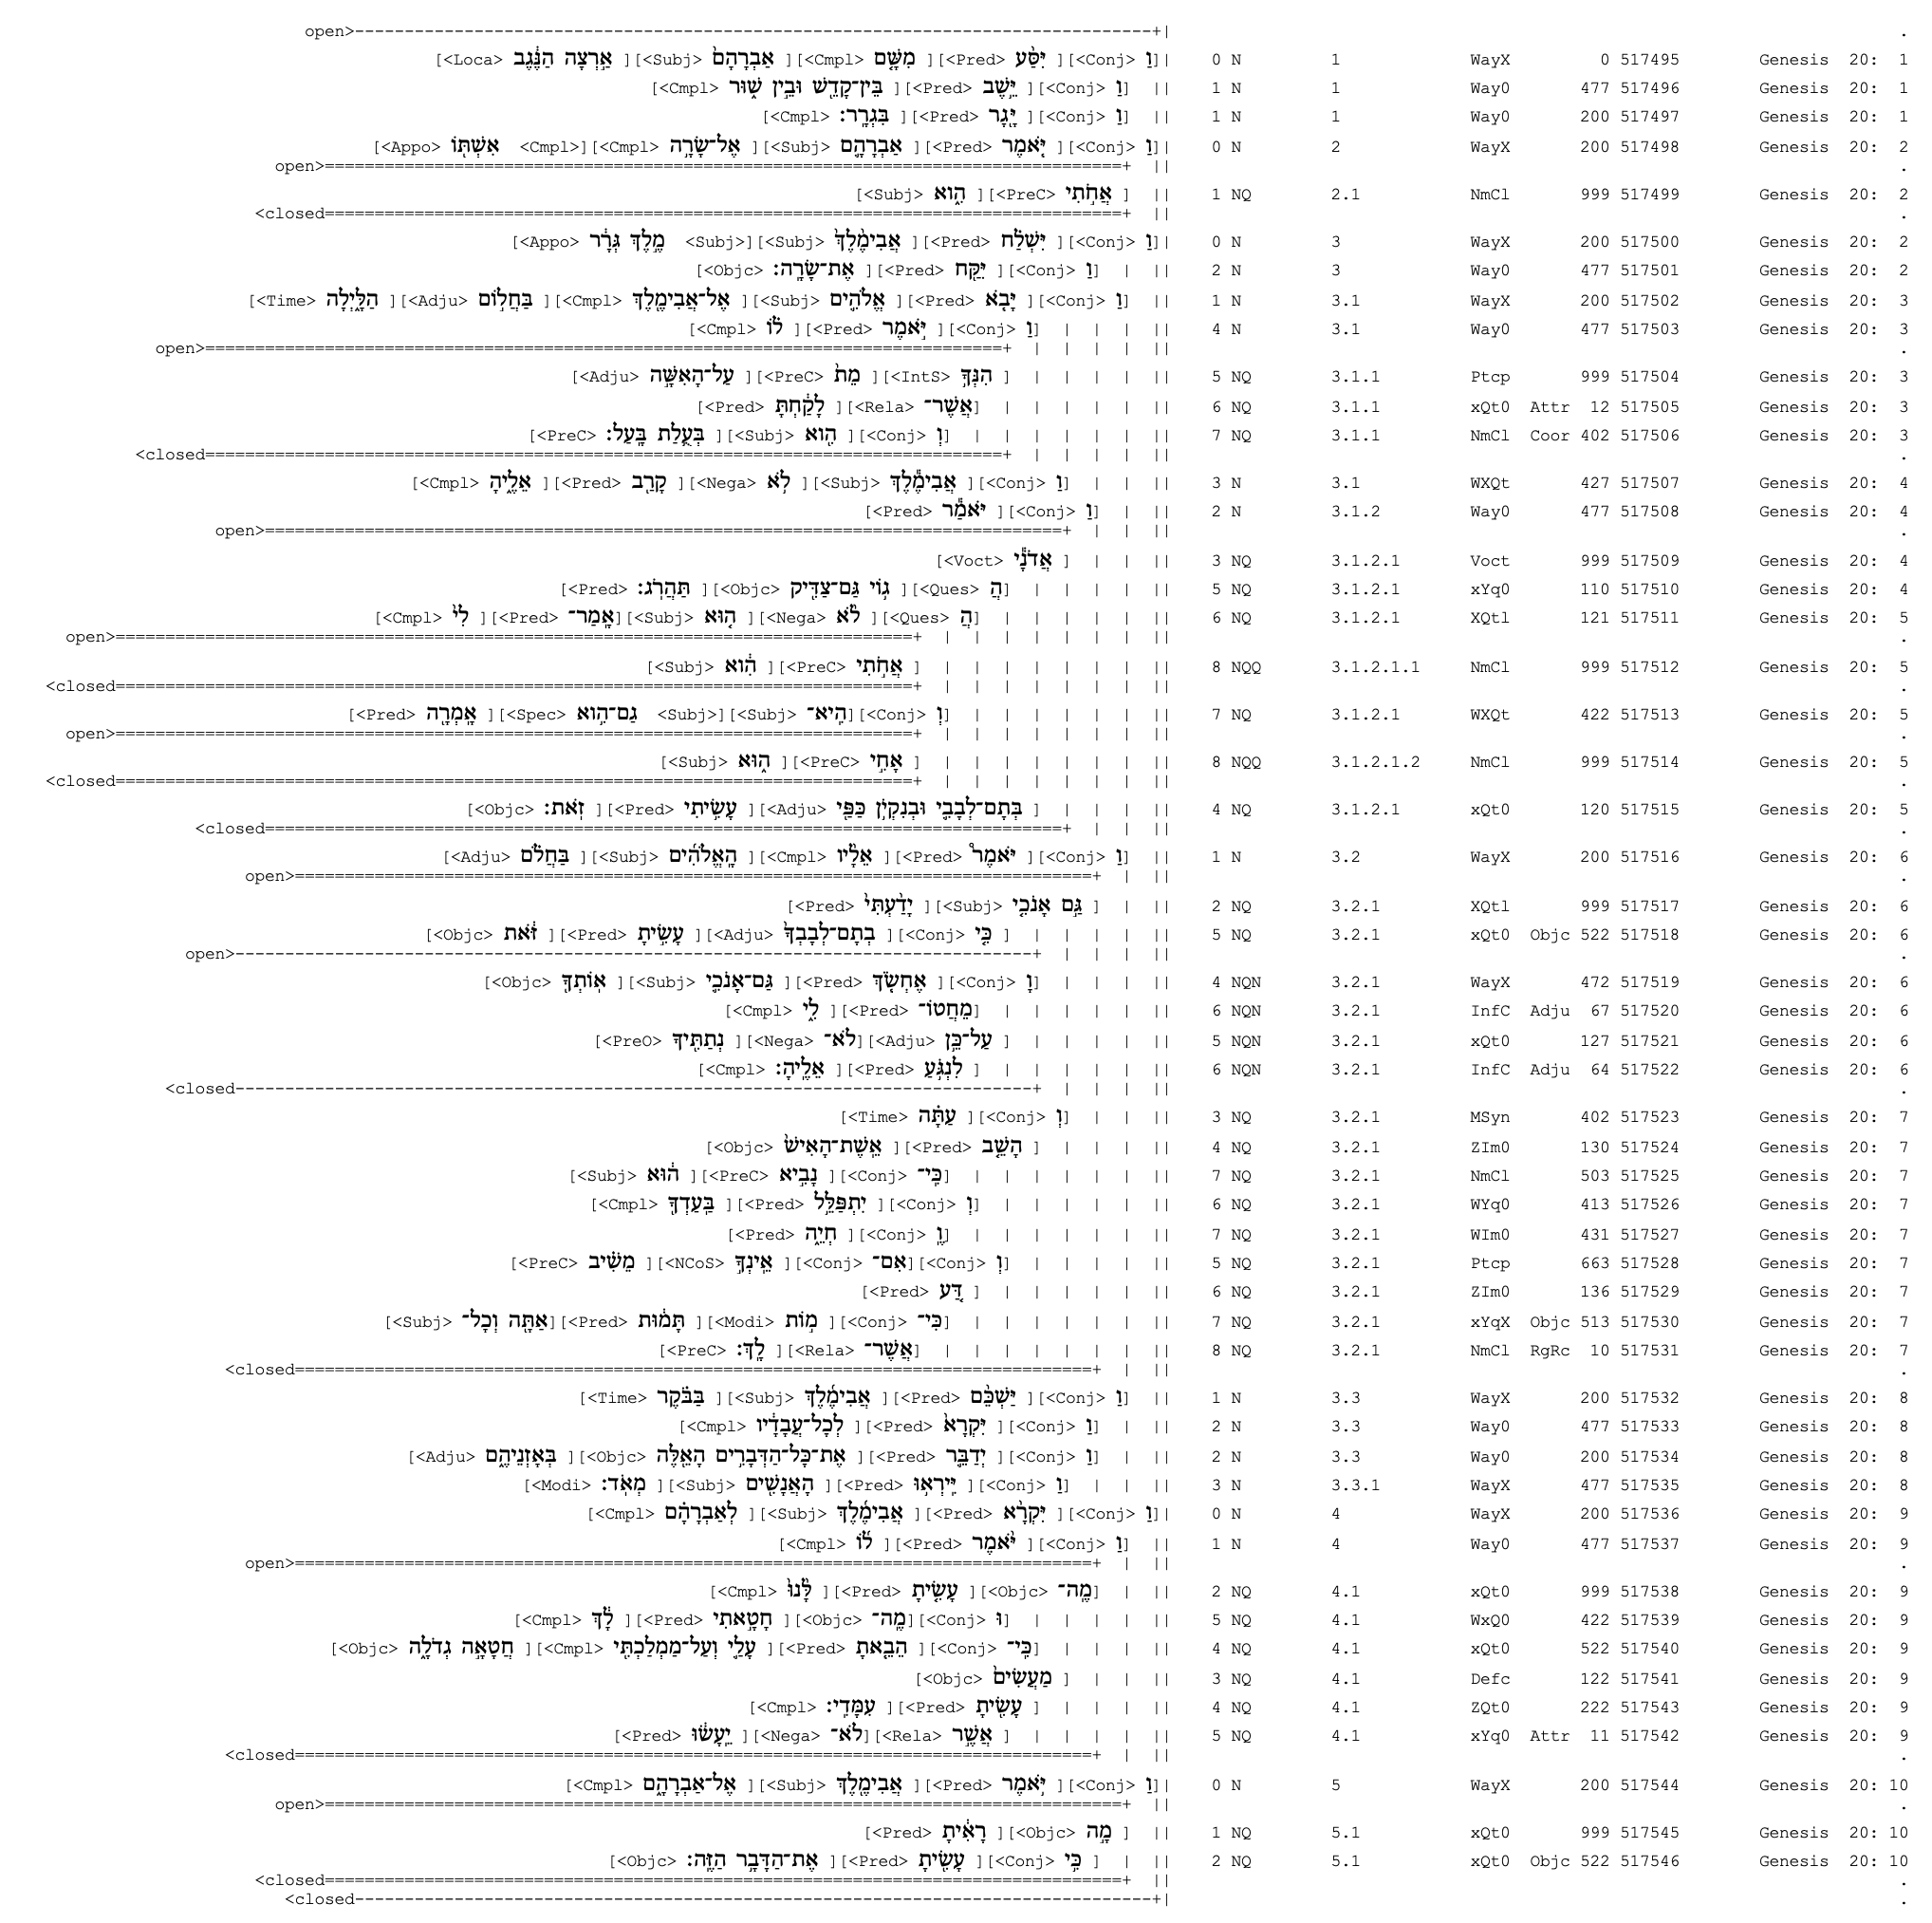